In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


# This is the IBM HR Analysis Dataset, where we have to predict whether an employee leaves or not. Since having employees leaving is costly and Time-consuming, we will prioritize the F2 Score, which puts more emphasis on the Recall. In a buisness scenario, it is much cheaper to accidently perform some extra retention intervention, than to lose a bunch of Employees.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


In [3]:
# Getting path
import os
print(os.listdir(path))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [4]:
# Get the data as a DF
import pandas as pd

#Create full file path
file_path = os.path.join(path, 'WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Load into a DF
df = pd.read_csv(file_path)

df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [5]:
# Seeing the Min/Max values of all features
df.describe()

# As we can see, data have very different values, so we will need to scale data.

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
# Seeing the different dtypes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

We will run a code snippet to detect constants in out data.Constants are useless since they are the same value for all instances, providing no real information to the model

In [8]:
# Detecting all constant values
constants = [col for col in df.columns if df[col].nunique() == 1 ]
constants

['EmployeeCount', 'Over18', 'StandardHours']

In [9]:
# Now we will drop these columns
df = df.drop(columns=constants)

In [10]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [11]:
# Now looking at the Target variable
df['Attrition']

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: object

In [12]:
# Converting it into Int Values from Boolean values
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [13]:
# Looking at the percentage of Target variable
X = df.drop(columns=['Attrition'])
y = df['Attrition']

y.value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

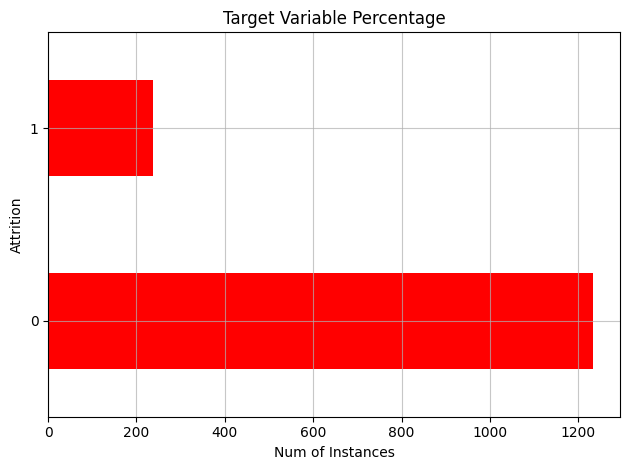

In [14]:
# Plotting it out for easier visualization
import matplotlib.pyplot as plt

plt.title('Target Variable Percentage')
y.value_counts().plot(
    kind='barh', color='red')
plt.xlabel('Num of Instances')
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

## Looking at this graph, we can clearly see that the data is unbalanced. We will use this information later on, and we will use some Over sampling techniques like SMOTE.

# Now we will split our data into Train/Test split

In [15]:
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, shuffle=True, stratify=y, random_state=42)

In [16]:
# We will check if stratify worked
og_y = y.sum() / len(y)
train_y = y_train1.sum() / len(y_train1)
test_y = y_test1.sum() / len(y_test1)
print(f'OG Y percentage: {og_y}')
print(f'Train Y percentage: {train_y}')
print(f'Test Y percentage: {test_y}')

"""
    As we can see, The stratify worked, since all of the datasets have the same percentage of y values.
"""

OG Y percentage: 0.16122448979591836
Train Y percentage: 0.16152450090744103
Test Y percentage: 0.16032608695652173


'\n    As we can see, The stratify worked, since all of the datasets have the same percentage of y values.\n'

# Now we will Scale and Encode data
## If we dont scale data, then the Model will think that features with a higher value matter more than lower value features, which is not True. Also, we Encode data since Models cannot handle STR types, so we use One Hot Encoding to fix this problem.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

scaler = StandardScaler()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

object_columns = X_train1.select_dtypes(include=object).columns
int_columns = X_train1.select_dtypes(include=int).columns

preprocessing = ColumnTransformer([
    ('int',scaler, int_columns),
    ('object', ohe, object_columns),
],     remainder='passthrough')

In [18]:
X_train = preprocessing.fit_transform(X_train1,y_train1)
X_test = preprocessing.transform(X_test1)

In [19]:
X_train = pd.DataFrame(X_train, columns=preprocessing.get_feature_names_out())
X_test = pd.DataFrame(X_test, columns=preprocessing.get_feature_names_out())

In [20]:
X_train

,int__Age,int__DailyRate,int__DistanceFromHome,int__Education,int__EmployeeNumber,int__EnvironmentSatisfaction,int__HourlyRate,int__JobInvolvement,int__JobLevel,int__JobSatisfaction,...,object__JobRole_Manufacturing Director,object__JobRole_Research Director,object__JobRole_Research Scientist,object__JobRole_Sales Executive,object__JobRole_Sales Representative,object__MaritalStatus_Divorced,object__MaritalStatus_Married,object__MaritalStatus_Single,object__OverTime_No,object__OverTime_Yes
0,-0.319271,-0.966810,-0.285354,1.068343,-1.659162,-1.577764,-0.605091,0.370808,0.859399,-0.641268,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,-0.101078,-1.685283,-0.407522,0.097763,-1.543309,-0.656844,-0.506799,1.784752,-0.984919,1.159183,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-1.628429,-1.036905,-0.285354,-1.843398,1.447044,1.184994,0.476116,0.370808,-0.984919,-0.641268,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.226212,-0.751519,-0.896194,1.068343,-1.130268,0.264075,-0.064487,0.370808,0.859399,0.258958,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.101078,0.222300,-1.018362,1.068343,1.084373,1.184994,-1.588006,-1.043137,-0.062760,0.258958,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,0.989888,0.848147,-0.285354,1.068343,-0.888487,0.264075,-1.735444,0.370808,-0.062760,0.258958,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1098,0.117115,0.510189,-0.896194,-0.872817,0.568911,-0.656844,-1.686298,0.370808,-0.062760,-1.541493,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1099,-1.628429,-1.472495,-0.163186,-1.843398,0.004757,-0.656844,1.409886,-2.457082,-0.984919,-1.541493,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1100,-0.101078,-0.939273,-0.896194,1.068343,1.394994,1.184994,0.377825,0.370808,-0.062760,-0.641268,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [21]:
X_test

,int__Age,int__DailyRate,int__DistanceFromHome,int__Education,int__EmployeeNumber,int__EnvironmentSatisfaction,int__HourlyRate,int__JobInvolvement,int__JobLevel,int__JobSatisfaction,...,object__JobRole_Manufacturing Director,object__JobRole_Research Director,object__JobRole_Research Scientist,object__JobRole_Sales Executive,object__JobRole_Sales Representative,object__MaritalStatus_Divorced,object__MaritalStatus_Married,object__MaritalStatus_Single,object__OverTime_No,object__OverTime_Yes
0,-0.973850,1.030894,-1.018362,0.097763,1.373167,0.264075,0.082950,0.370808,-0.984919,-1.541493,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.537464,0.430081,-0.896194,0.097763,1.099485,1.184994,-0.998257,0.370808,-0.062760,-0.641268,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.537464,-0.511193,-0.285354,2.038923,0.721703,1.184994,1.557324,0.370808,-0.062760,1.159183,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.319271,-0.318432,1.180662,0.097763,1.149855,-0.656844,-1.489715,-1.043137,-0.984919,1.159183,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.226212,-1.662752,-0.774026,0.097763,-0.430112,0.264075,-1.047403,1.784752,-0.062760,-0.641268,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,-0.755657,0.289891,-1.018362,0.097763,-0.352877,1.184994,-1.342277,-2.457082,-0.984919,0.258958,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
364,0.008019,-0.586295,0.081150,-1.843398,-0.359593,1.184994,0.820137,0.370808,-0.984919,-1.541493,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
365,-1.192043,1.448960,-0.774026,1.068343,0.270044,-1.577764,0.820137,1.784752,-0.984919,1.159183,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
366,1.862660,-1.627705,-0.041018,-0.872817,1.599836,-1.577764,0.082950,0.370808,-0.062760,0.258958,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## We will now use umap to view the global structure of the data

In [22]:
import umap

umap = umap.UMAP(n_neighbors=60, n_components=2,random_state=42)
fitted_umap = umap.fit_transform(X_train)

2026-03-20 03:31:35.060230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773977495.286031      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773977495.341905      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773977495.808735      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773977495.808777      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773977495.808781      24 computation_placer.cc:177] computation placer alr

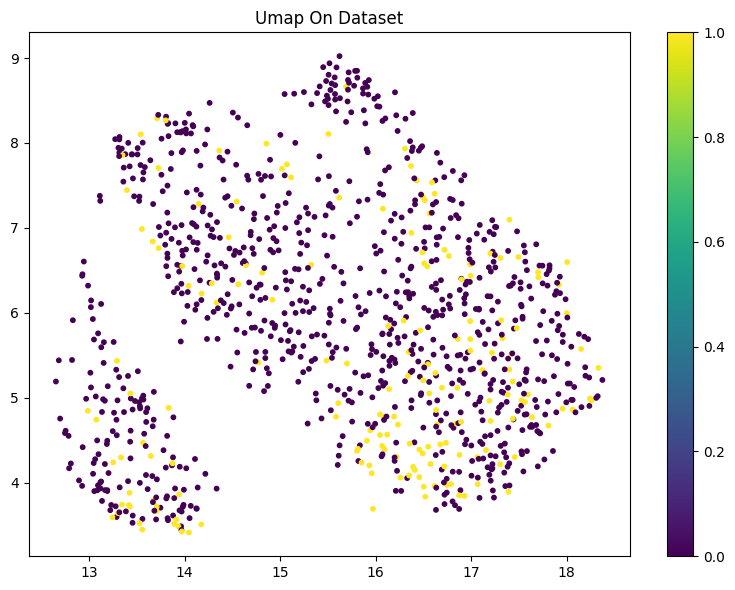

In [23]:
# plotting UMAP
plt.figure(figsize=(8,6))
plt.scatter(fitted_umap[:,0], fitted_umap[:,1], c=y_train1, s=10)
plt.colorbar()
plt.title('Umap On Dataset')
plt.tight_layout()
plt.show()

## Now we are just going to establish a baseline with a Logistic Regression Model, and a RFR Model, to see how muxh better XGBoost model performs

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, classification_report, fbeta_score, make_scorer
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [25]:
lr = LogisticRegression(max_iter=10000)
rfr = RandomForestClassifier(random_state=42)

# Making custom cv
k = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Makign custom F2 Scorer
f2_score = make_scorer(fbeta_score, beta=2)


# Using Cross Validation to get the scores for both models
lr_score = cross_val_score(lr, X_train, y_train1, cv=k, n_jobs=-1, scoring=f2_score)
rfr_score = cross_val_score(rfr, X_train, y_train1, cv=k, n_jobs=-1, scoring=f2_score)

# Printing out results
print(f'LR results: {lr_score.mean()}')
print(f'RFR results: {rfr_score.mean()}')

LR results: 0.5029471620834102
RFR results: 0.21201227021598124


In [26]:
lr.fit(X_train, y_train1)
rfr.fit(X_train, y_train1)

lr_pred = lr.predict(X_test)
rfr_pred = rfr.predict(X_test)

In [27]:
lr_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [28]:
# Viewing Classification Report
print('Classification Report for LR')
print(classification_report(y_test1, lr_pred), '\n\n')
print('Classification Report for RFR')
print(classification_report(y_test1, rfr_pred))

Classification Report for LR
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       309
           1       0.66      0.36      0.46        59

    accuracy                           0.87       368
   macro avg       0.77      0.66      0.69       368
weighted avg       0.85      0.87      0.85       368
 


Classification Report for RFR
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       309
           1       0.55      0.10      0.17        59

    accuracy                           0.84       368
   macro avg       0.70      0.54      0.54       368
weighted avg       0.80      0.84      0.79       368



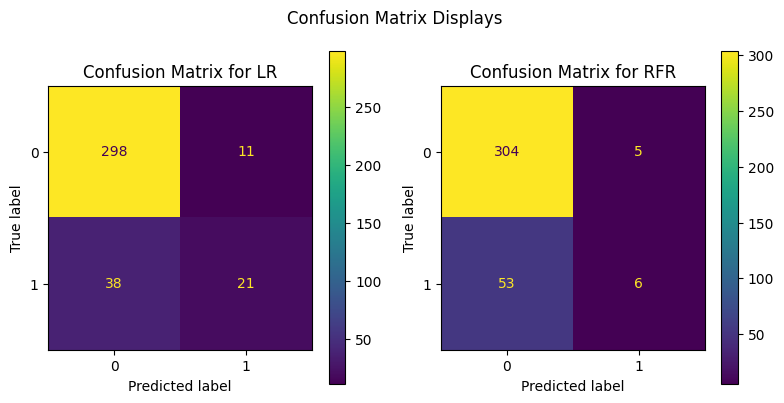

In [29]:
# Viewing Confusion Matrices
fig, ax = plt.subplots(1,2, figsize=(8,4))

# Confusion Matrix for LR
ConfusionMatrixDisplay.from_predictions(y_test1, lr_pred, ax=ax[0])

# Confusion Matrix for RFR
ConfusionMatrixDisplay.from_predictions(y_test1, rfr_pred, ax=ax[1])

# Adding Titles
fig.suptitle('Confusion Matrix Displays')
ax[0].set_title('Confusion Matrix for LR')
ax[1].set_title('Confusion Matrix for RFR')
plt.tight_layout()
plt.show()

## Now we will use XGBoost as a Baseline model to see if it can beat the previous two Models. We will very briefly also perform Hyperparameter Tuning with Optuna, but this is just for a baseline score. We will not spend too much time here, since we will also perform Feature Selection later.

In [30]:
import xgboost as xgb
import optuna
import numpy as np

# Calculating the Class Imbalance (Should be around 5-6)
neg = (y_train1 == 0).sum()
posi = (y_train1 ==1).sum()
pos_weight = neg / posi



# Creating XGBoost Model
# ----------------------------BASE MODEL---------------------------------
xgb_base = xgb.XGBClassifier(
    objective = 'binary:logistic',
    # We use AUC as the Evaluation metric and not our custom F2 score, cause cusotm scorers cannot be used here, and also it requires probs
    # but XGBoost outputs predictions.
    eval_metric='auc',
    # Fraction of rows used in each Tree
    subsample=0.8,
    # Fraction of features used by each Tree
    colsample_bytree=0.8,
    # This is critical for Class Imbalance
    scale_pos_weight=pos_weight,
    # Setting n_estimators to a high value since we will Prune and perform Early Stopping
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1
)


xgb_base.fit(
    X_train,
    y_train1, 
    eval_set=[(X_train, y_train1), (X_test, y_test1)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [31]:
# Looking at the eval set results to see if Model was either Overfitting/Underfitting on data.
xgb_base_train_scores = pd.DataFrame(xgb_base.evals_result()['validation_0'])
xgb_base_test_scores = pd.DataFrame(xgb_base.evals_result()['validation_1'])
# Renaming colunms for easier readability
xgb_base_train_scores.columns = ['Train']
xgb_base_test_scores.columns = ['Test']
# Combining both of the DF's for easier access
xgb_base_evals_df = pd.concat((xgb_base_train_scores, xgb_base_test_scores), axis=1)

In [32]:
np.argmax(xgb_base_test_scores)

np.int64(5)

In [33]:
xgb_base_evals_df.mean(axis=0)

Train    0.990914
Test     0.776225
dtype: float64

In [34]:
nums = []
for i in range(56):
    nums.append(i + 1)

In [35]:
min(nums)

1

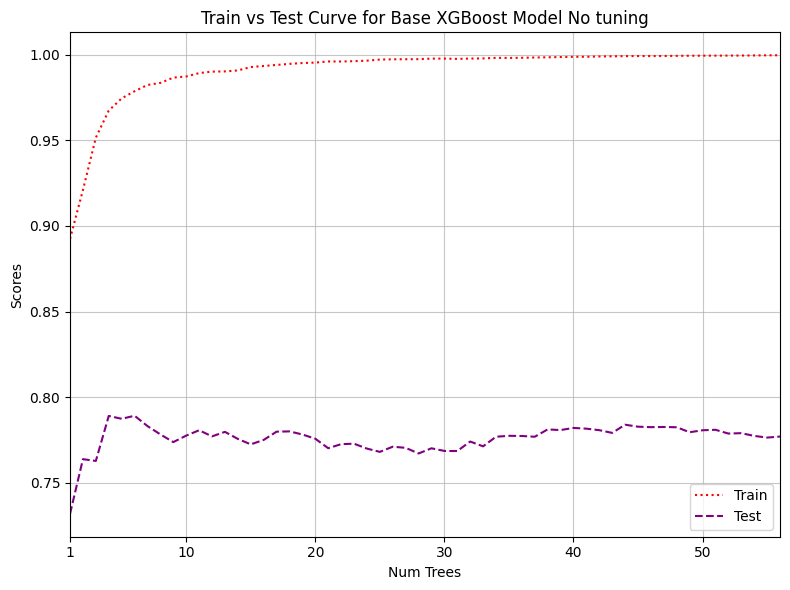

In [36]:
# Plot it
plt.figure(figsize=(8,6))

plt.plot(nums, xgb_base_train_scores, linestyle=':', color='red', label='Train')
plt.plot(nums, xgb_base_test_scores, linestyle='--', color='purple', label='Test')
plt.xlim(min(nums), max(nums))
plt.xticks([1,10,20,30,40,50])
plt.title('Train vs Test Curve for Base XGBoost Model No tuning')
plt.xlabel('Num Trees')
plt.ylabel('Scores')
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.7)
plt.show()

## As we can see with the evals_result function, the base XGBoost model is severly overfitting.

In [37]:
# Get the Base Scores for this Model
from sklearn.metrics import roc_auc_score

# Get probs
y_base_probs = xgb_base.predict_proba(X_test)[:,1]

xgb_base_score = roc_auc_score(y_test1, y_base_probs)

print(f'Base Roc Score: {xgb_base_score}')
print(f'Best Iteration: {xgb_base.best_iteration}')
print(f'Best Score: {xgb_base.best_score}')
# .best_iteration & best_score both only look at the testing sets in eval_set in XGBoost

Base Roc Score: 0.7892326257473534
Best Iteration: 5
Best Score: 0.7892326257473534


## Now we will do a quick rough tune with our XGBoost model. This is not the final tune, it is just used to get roughly good hyperparameters before you do feature selection. That is why we will only run 50 trials, since we will tune later after feature selection.

In [38]:
pip install optuna-integration[xgboost]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 504.9 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [39]:
# We use this line of code to now show every single Trial when runnig studies since it takes up a lot of space.
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [40]:
# We now use optuna since it uses Bayesion optimization to find the best feature values
import optuna
# We use a Callback to send to the pruner to know when trees are useless
from optuna.integration import XGBoostPruningCallback

# We define an Objective function
def objective_rough(trial):

    # We define out callback first
    # This tells the model to 'kill' off a trial if it is bad
    pruner = XGBoostPruningCallback(trial, 'validation_1-auc')

    
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int('max_depth', 3,7),
        'gamma': trial.suggest_float('gamma', 0.01, 1),
        'max_leaves': trial.suggest_int('max_leaves', 0, 50),
        'n_estimators': trial.suggest_int('n_estimators', 100,500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5,1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8,5.0, log=True),
        'early_stopping_rounds': 100,
        'scale_pos_weight': pos_weight,
        'callbacks': [pruner],
        'random_state': 42,
        'n_jobs': -1,
    }

    # We instantiate the model with all of the params
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train1,
        eval_set=[(X_train, y_train1), (X_test, y_test1)],
    )


    #Return the best score
    return model.best_score

In [41]:
# create the rough study
rough_study = optuna.create_study(
    study_name='rough_study',
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
    sampler = optuna.samplers.TPESampler(seed=42) # <- This makes it so we get same results each time
)

# now we optimize the study using the Objective function defined above
rough_study.optimize(objective_rough, n_trials=70, show_progress_bar=True)

  0%|          | 0/70 [00:00<?, ?it/s]

[0]	validation_0-auc:0.77085	validation_1-auc:0.65844
[1]	validation_0-auc:0.81325	validation_1-auc:0.65827
[2]	validation_0-auc:0.84383	validation_1-auc:0.65685
[3]	validation_0-auc:0.85667	validation_1-auc:0.71047
[4]	validation_0-auc:0.86278	validation_1-auc:0.72363
[5]	validation_0-auc:0.88019	validation_1-auc:0.73345
[6]	validation_0-auc:0.88691	validation_1-auc:0.74782
[7]	validation_0-auc:0.89116	validation_1-auc:0.75086
[8]	validation_0-auc:0.89628	validation_1-auc:0.75808
[9]	validation_0-auc:0.89838	validation_1-auc:0.74661
[10]	validation_0-auc:0.90160	validation_1-auc:0.74379
[11]	validation_0-auc:0.89857	validation_1-auc:0.75772
[12]	validation_0-auc:0.90155	validation_1-auc:0.75904
[13]	validation_0-auc:0.90419	validation_1-auc:0.76189
[14]	validation_0-auc:0.90800	validation_1-auc:0.76288
[15]	validation_0-auc:0.90959	validation_1-auc:0.76129
[16]	validation_0-auc:0.91317	validation_1-auc:0.75904
[17]	validation_0-auc:0.91420	validation_1-auc:0.76447
[18]	validation_0-au

In [42]:
# Now that we have fininshed our Hyperparameter Tuning session, we will retreive the best params and see the best score

best_params_rough = rough_study.best_params
best_value_rough = rough_study.best_value

print(f'Best Rough Params: {best_params_rough}')
print(f'Best Rough Score: {best_value_rough}')

Best Rough Params: {'max_depth': 3, 'gamma': 0.638054391006843, 'max_leaves': 22, 'n_estimators': 376, 'learning_rate': 0.28695239082531654, 'subsample': 0.5230115115999981, 'colsample_bytree': 0.960962343824338, 'reg_alpha': 2.822224898073651, 'reg_lambda': 0.0003752139127060336}
Best Rough Score: 0.804179693927925


In [43]:
# Now we will create a new XGBoost model on the best hyperparams found by rough search
# We have to be careful not to just train the model wiht .fit() and call it a day: I did that mistake and it ended up hurting the score.
# The model uses the same params, but without any early stopping, and any other params. This is a common mistake, so we ahve to be careful of that here
rough_xgb = xgb.XGBClassifier(
    **best_params_rough,
    # We do not prune outside of Optuna, since the callback would have nothing to report back to, and we do not prune when fitting()
    n_jobs=-1,
    scale_pos_weight=pos_weight,
    early_stopping_rounds=100,
    eval_metric='auc',
    objective='binary:logistic'
)

# Now we fit the model
rough_xgb.fit(
    X_train, y_train1,
    eval_set=[(X_train, y_train1), (X_test, y_test1)],
    verbose=False,

)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.960962343824338, device=None,
              early_stopping_rounds=100, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.638054391006843, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.28695239082531654,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=22,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=376, n_jobs=-1,
              num_parallel_tree=None, ...)

In [44]:
rough_train = pd.DataFrame(rough_xgb.evals_result_['validation_0'])
rough_test = pd.DataFrame(rough_xgb.evals_result_['validation_1'])
rough_train.columns = ['Train']
rough_test.columns= ['Test']
rough_xgb_results = pd.concat((rough_train, rough_test), axis=1)
rough_xgb_results.mean(axis=0)

Train    0.979509
Test     0.769663
dtype: float64

In [45]:
# Now predicting probs for X_test
rough_probs = rough_xgb.predict_proba(X_test)[:,1]
rough_auc = roc_auc_score(y_test1, rough_probs)
print(f'Base XGB after Tuning AUC score: {rough_auc}')
print(f'Base Roc Score: {xgb_base_score}')

Base XGB after Tuning AUC score: 0.7905216389665954
Base Roc Score: 0.7892326257473534


In [46]:
# Seeing if early stopping worker
rough_xgb.best_iteration

48

In [47]:
rough_xgb.best_score

0.7905216389665953

## Even though the AUC score for this new tuned model is worse than the untuned XGB model, it does not matter to us right not. We only tuned for feature importances for trustworthieness, and any reasonably configured model is better than an untuned model, no matter if its AUC score is less. And, 50 Trils is not enough to learn the patterns in the data for 7+ params, even if the data is small (~1000 rows).

# Now we will generate SHAP Values for feature selection

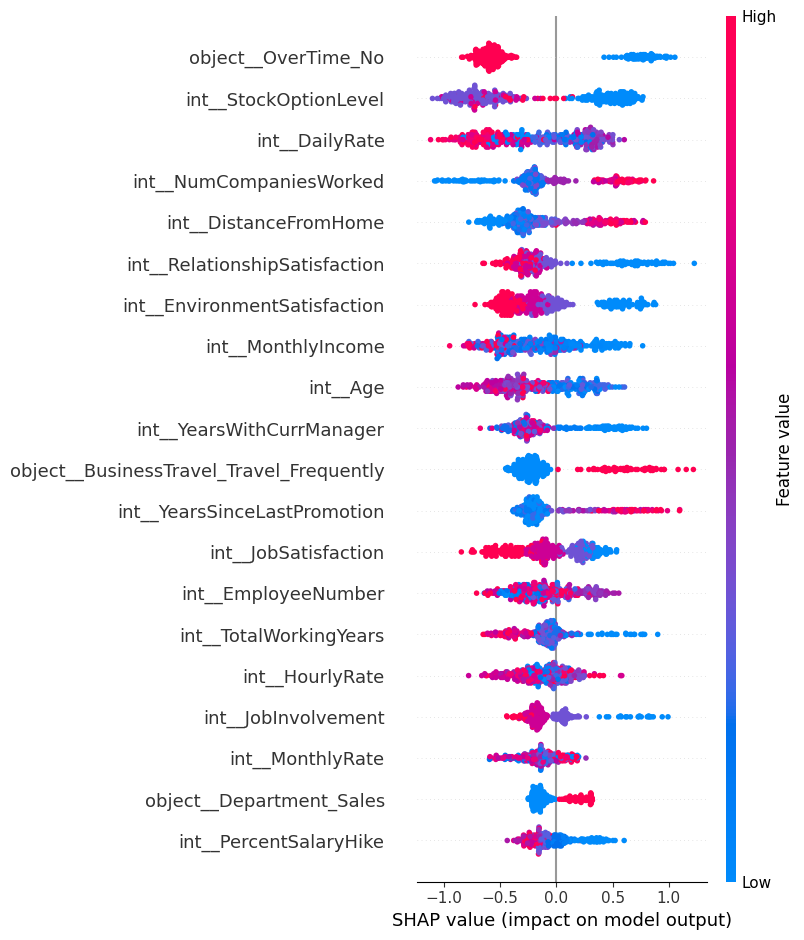

In [48]:
import shap

feature_selection_model = rough_xgb

# Make the explainer
explainer = shap.TreeExplainer(feature_selection_model)
shap_values = explainer.shap_values(X_test)

# Visual summary
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.to_list())
# Lower SHAP values make it lean toward the negative class 0, and Higher SHAP values push it to the positive class 1.
# By default, shap.summary_plot only shwos top 10 most important features

In [49]:
shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values(by='shap_importance', ascending=False).reset_index(drop=True)

# Now we will make a df containign the cumulative sum of the shap_importances so we can find the features retaining 95% of the total variance
shap_df['cumulative'] = (shap_df['shap_importance'].cumsum() / shap_df['shap_importance'].sum())

# Find top features
top_features = shap_df[shap_df['cumulative'] <= 0.95]['feature'].to_list()

# Make new Datasets 
X_train_shap = X_train[top_features]
X_test_shap = X_test[top_features]

## As we can see by the new shape of the datsets, we have reduced the amount of features in our data by half. 
## The technique we used was we ordered the data by SHAP values, then we deleted all of the features with around 0 Shap Importance, since they had little say in the models prediction.

In [50]:
X_test.shape

(368, 52)

## Now we will check the Pearsons Corr Coefficient and delete features with a high (> 0.85, <-0.85) score. 

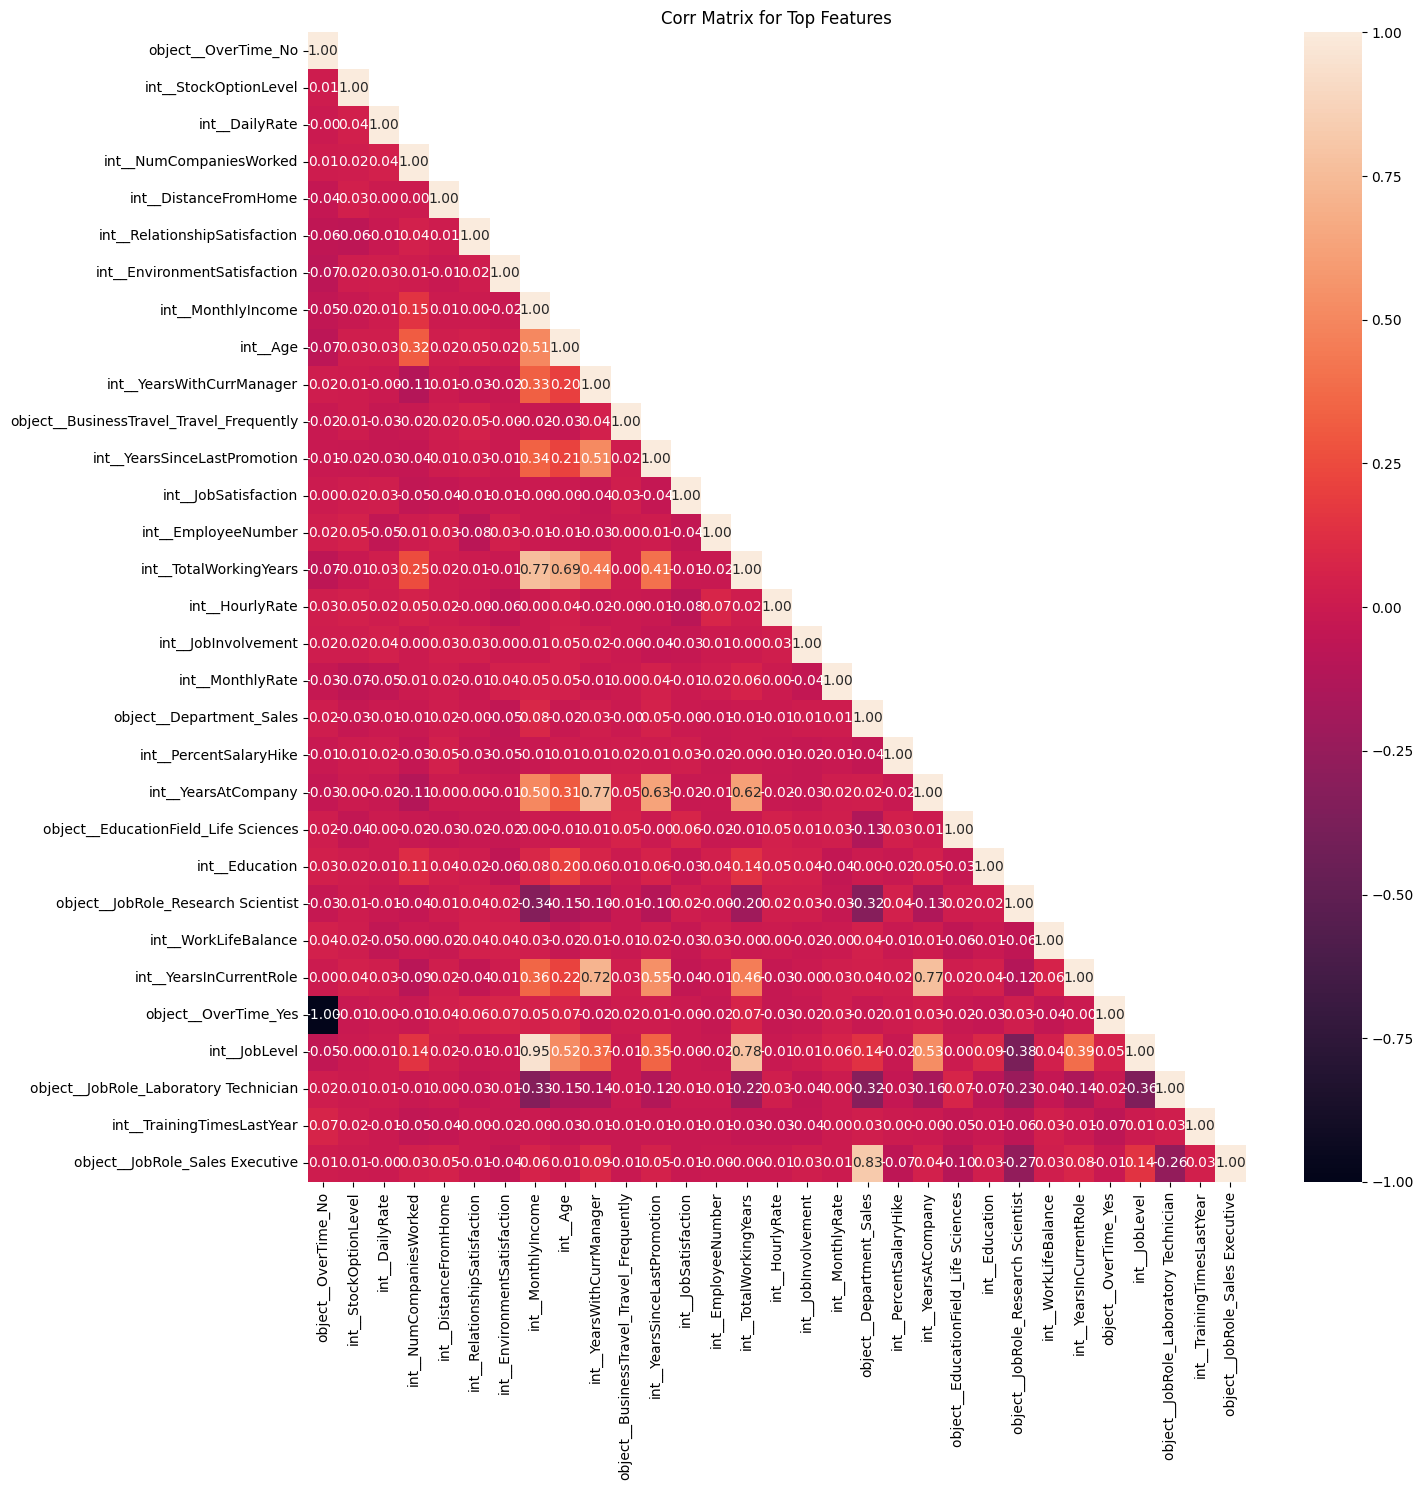

In [51]:
import seaborn as sns
# Caluclate the Math
corr_rough = X_train_shap.corr()

# Plot it using Seaborn Heatmap
plt.figure(figsize=(15,15))
# Now we only use the upper triangle. Since a Corr matrix is symetrical, all values above and underneath the diagonal (always 1.00) are the exact same
# when we use the following code, it changes all of the values to True, then it makes the values False that are underneath the Diagonal.
# We will use this as the argument for the 'mask' parameter, which does not show anything with a bool value fo TRUE
# 'k=1' shows the Diagonal with all 1.00 Values
upper_triangle = np.triu(np.ones_like(corr_rough, dtype=bool), k=1)
# plot using SNS.HEATMAP
sns.heatmap(corr_rough, mask=upper_triangle, annot=True, fmt='.2f')
plt.title('Corr Matrix for Top Features')
plt.tight_layout()
plt.show()

## Now we will search for all Features with higher Pearsons Corr Coefficient than 0.85, and remove them. We only keep the one with the higher SHAP value.

In [52]:
# We search for the Highest score columns
higher_corr_pairs=[]
for i in range(len(corr_rough.columns)):
    for j in range(i):
        if abs(corr_rough.iloc[i,j]) >=0.85:
            higher_corr_pairs.append((
                corr_rough.columns[i],
                corr_rough.columns[j],
                corr_rough.iloc[i,j],
            ))


# Turn into a DF
highest_corr_df = pd.DataFrame(higher_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
highest_corr_df

# Job Level - Higher SHAP importance than MonthlyIncome
# OverTime_No - Higher SHAP importance than OverTime_Yes

# According to these Results, we will drop Monthly Income & OverTime_Yes

,Feature_1,Feature_2,Correlation
0,object__OverTime_Yes,object__OverTime_No,-1.000000
1,int__JobLevel,int__MonthlyIncome,0.946542


In [53]:
# Dropping both columns
X_train_new = X_train_shap.drop(columns=['int__MonthlyIncome', 'object__OverTime_Yes'], axis=1)
X_test_new = X_test_shap.drop(columns=['int__MonthlyIncome', 'object__OverTime_Yes'])
print(f'New Train Shape: {X_train_new.shape}')
print(f'New Test Shape: {X_test_new.shape}')

New Train Shape: (1102, 29)
New Test Shape: (368, 29)


# Now we are going to do some Feature Engineering and create some new columns

In [54]:
X_test_new.columns

Index(['object__OverTime_No', 'int__StockOptionLevel', 'int__DailyRate',
       'int__NumCompaniesWorked', 'int__DistanceFromHome',
       'int__RelationshipSatisfaction', 'int__EnvironmentSatisfaction',
       'int__Age', 'int__YearsWithCurrManager',
       'object__BusinessTravel_Travel_Frequently',
       'int__YearsSinceLastPromotion', 'int__JobSatisfaction',
       'int__EmployeeNumber', 'int__TotalWorkingYears', 'int__HourlyRate',
       'int__JobInvolvement', 'int__MonthlyRate', 'object__Department_Sales',
       'int__PercentSalaryHike', 'int__YearsAtCompany',
       'object__EducationField_Life Sciences', 'int__Education',
       'object__JobRole_Research Scientist', 'int__WorkLifeBalance',
       'int__YearsInCurrentRole', 'int__JobLevel',
       'object__JobRole_Laboratory Technician', 'int__TrainingTimesLastYear',
       'object__JobRole_Sales Executive'],
      dtype='object')

In [55]:
# We will add Stock_with_years_in_company, Age_years_current_role, and Job_involvement_with_involvment

# We need to be careful here. If someone is new and has 0 years at the company, we will divide by 0, crashing code. We will add a +1 buffer
X_train_new['Stock_with_years_in_company'] =  X_train_new['int__StockOptionLevel']/ (X_train_new['int__YearsAtCompany'] + 1)

# Seeing when they got hired
X_train_new['Age_at_hire'] = X_train_new['int__Age'] - (X_train_new['int__YearsAtCompany'] + 1)

# Higher score means both involved and Satisfied
X_train_new['Happiness_with_Engagement'] = X_train_new['int__JobSatisfaction']  + X_train_new['int__JobInvolvement']

# Lower score means more job hopping, higher score means loyal
X_train_new['JobHopper'] = X_train_new['int__YearsAtCompany'] - X_train_new['int__NumCompaniesWorked']

## Now we will calculate the Mutual Info Classif against the target data to see how much each of these new features is correlated with the target variable. We wont use Pearsons Corr anymore, since it assumes data is linear, which is extremely rare in real-world scenarios.
## Always we would do Feature Engineering before Feature Selection, But this project is mroe focused on XGBoost, so we will not bother for this project.

In [56]:
from sklearn.feature_selection import mutual_info_classif

# Calculate MI Scores
mi_scores = mutual_info_classif(
    X_train_new,
    y_train1,
    random_state=42,
)

# Turn it into a DF for easier readability
mi_df = pd.DataFrame({
    'features': X_train_new.columns,
    'mi_scores': mi_scores
}).sort_values(by='mi_scores', ascending=False).reset_index(drop=True)

"""
    How to interpret results:
        mi_score: 0 -> Features share no info with target
        mi_score: 0.01-0.05 -> Features share little info, weak relationship, borderline
        mi_score: 0.05-0.15 -> Moderate realtionship, worth keeping
        mi_score: 0.15+ -> Strong relationship with target, Absolutely Keep
"""

'\n    How to interpret results:\n        mi_score: 0 -> Features share no info with target\n        mi_score: 0.01-0.05 -> Features share little info, weak relationship, borderline\n        mi_score: 0.05-0.15 -> Moderate realtionship, worth keeping\n        mi_score: 0.15+ -> Strong relationship with target, Absolutely Keep\n'

In [57]:
mi_df

,features,mi_scores
0,int__YearsInCurrentRole,0.042501
1,Stock_with_years_in_company,0.040339
2,int__JobLevel,0.033355
3,int__TotalWorkingYears,0.033010
4,JobHopper,0.031891
5,int__YearsAtCompany,0.030532
6,int__JobInvolvement,0.028142
7,int__YearsWithCurrManager,0.027604
8,int__HourlyRate,0.022559
9,Age_at_hire,0.022039


## WOW! As we can see, our engineered features are actually doing better than the normal features. 'Stock_with_years_in_company' is the number one feature in this. This tells us our Feature Engineering actually worked. Now, we will drop all of the Features with absolutely 0 MI Score. As we can see though, the highest score is 0.05, which is the second lowest score that it can get according to our listing up above in red. This however is normal, since it is rare where we have a feature that single handedly predicts if a person will churn or not

In [58]:
# Selecting all features with 0 score for MI
mi_dropping = mi_df[mi_df['mi_scores'] == 0]['features']

# Now we will drop all features with score of 0
mi_df_new = mi_df.drop(mi_dropping.index)
final_features = mi_df_new['features'].to_list()

# Making X_train only contains selected features

final_X_train = X_train_new[final_features]
final_X_train.shape


(1102, 24)

In [59]:
# Adding all Engineered Features to X Test set

X_test_new['Stock_with_years_in_company'] =  X_test_new['int__StockOptionLevel']/ (X_test_new['int__YearsAtCompany'] + 1)
X_test_new['Age_at_hire'] = X_test_new['int__Age'] - (X_test_new['int__YearsAtCompany'] + 1)
X_test_new['Happiness_with_Engagement'] = X_test_new['int__JobSatisfaction']  + X_test_new['int__JobInvolvement']
X_test_new['JobHopper'] = X_test_new['int__YearsAtCompany'] - X_test_new['int__NumCompaniesWorked']

# Makign final X test set
final_X_test = X_test_new[final_features]
final_X_test.shape


(368, 24)

In [60]:
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
#  Making sure Feature engineering helped us and didnt hurt us
"""base_cv = cross_val_score(
    rough_xgb,
    X_train,
    y_train1,
    scoring='roc_auc',
    n_jobs=-1,
    cv=cv
)

after_cv = cross_val_score(
    rough_xgb,
    final_X_train,
    y_train1,
    scoring='roc_auc',
    n_jobs=-1,
    cv=cv
    
)"""


# Now, the reason I but brackets around these lines of code, is cause this is what I ran earlier and it did not work. Turns out, that when calling
# Cross_val_score, the fucntion internally calles model.fit() on the data. But, XGBoost looks around for a validation set so that it can utilize its 
# Early-Stopping technique. To fix this, we can do 2 things. First, we can either use .set_params(), and turn off early stopping, callbacks, and lower
# The amount n_estimators in the XGBoost model, since there will be no early stopping, and we dont want the model to overifit. Or, Secondly, we could
# Use the 'Pro Way', which is to use XGBoost's native cross_validate function, xgb.cv(). This new cv func is specifically desgined to work with
# Early Stopping across multiple folds simultaneously, and it builds a DMatrix, managing all validation sets for us.

"base_cv = cross_val_score(\n    rough_xgb,\n    X_train,\n    y_train1,\n    scoring='roc_auc',\n    n_jobs=-1,\n    cv=cv\n)\n\nafter_cv = cross_val_score(\n    rough_xgb,\n    final_X_train,\n    y_train1,\n    scoring='roc_auc',\n    n_jobs=-1,\n    cv=cv\n    \n)"

## Doing the first option

In [61]:
# Seeing all params that are used by model
params = {k: v for k,v in rough_xgb.get_params().items() if v != None}
params


{'objective': 'binary:logistic',
 'colsample_bytree': 0.960962343824338,
 'early_stopping_rounds': 100,
 'enable_categorical': False,
 'eval_metric': 'auc',
 'gamma': 0.638054391006843,
 'learning_rate': 0.28695239082531654,
 'max_depth': 3,
 'max_leaves': 22,
 'missing': nan,
 'n_estimators': 376,
 'n_jobs': -1,
 'reg_alpha': 2.822224898073651,
 'reg_lambda': 0.0003752139127060336,
 'scale_pos_weight': np.float64(5.191011235955056),
 'subsample': 0.5230115115999981}

In [62]:
# Using .set_params() to turn off all settings not used by cross_val_score 

rough_xgb1 = rough_xgb.set_params(
    early_stopping_rounds=None,
    callbacks=None,
    n_estimators=200 # Setting to low value so no overfitting
    
)



base_cv = cross_val_score(
    rough_xgb1,
    X_train,
    y_train1,
    scoring='roc_auc',
    n_jobs=-1,
    cv=cv
)

after_cv = cross_val_score(
    rough_xgb1,
    final_X_train,
    y_train1,
    scoring='roc_auc',
    n_jobs=-1,
    cv=cv
    
)

# Print out scores
print(f'Base Dataset Cv Score: {base_cv.mean()}')
print(f'Selected Features Cv Score: {after_cv.mean()}')




Base Dataset Cv Score: 0.8085104760039543
Selected Features Cv Score: 0.8025973663104099


## Now doing the Optimized, xgb.cv approach:

In [63]:
# Convert data into a DMatrix
dtrain_base = xgb.DMatrix(X_train, label=y_train1)
dtrain_after = xgb.DMatrix(final_X_train, label=y_train1)

# Extract params from Model
rough_params = rough_xgb.get_params()

# Remove SKLearn parameters that cause conflict
for key in ['early_stopping_rounds', 'callbacks', 'n_estimators']:
    rough_params.pop(key, None)

# Run Native XGB CV:
base_xgb_cv = xgb.cv(
    params=rough_params,
    dtrain=dtrain_base,
    num_boost_round=600, # <- Max num of Trees
    nfold=5, # <- Num Folds
    stratified=True,
    metrics='auc',
    early_stopping_rounds=70,
    seed=42
)


after_xgb_cv = xgb.cv(
    params=rough_params,
    dtrain=dtrain_after,
    stratified=True,
    seed=42,
    metrics='auc',
    num_boost_round=600,
    early_stopping_rounds=70,
    nfold=5
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:225: UserWarning: [03:32:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "enable_categorical", "missing" } are not used.

  return getattr(self.bst, name)(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:231: UserWarning: [03:32:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "enable_categorical", "missing" } are not used.

  self.bst.update(self.dtrain, iteration, fobj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:225: UserWarning: [03:32:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "enable_categorical", "missing" } are not used.

  return getattr(self.bst, name)(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:231: UserWarning: [03:32:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "enable_categorical", "missing" } are not used.

  self.bst.update(self.dtrain, iteration, fobj)


In [64]:
# These functions return DataFrames:
# See the Test SUC Scores With the STD
print(f'Base XGB Native CV Test AUC Score: {base_xgb_cv['test-auc-mean'].mean()}. STD: {base_xgb_cv['test-auc-std'].mean()}')
print(f'After XGB Native CV Test AUC Score: {after_xgb_cv['test-auc-mean'].mean()}. STD: {after_xgb_cv['test-auc-std'].mean()}')

Base XGB Native CV Test AUC Score: 0.7926752513045046. STD: 0.028900654132214956
After XGB Native CV Test AUC Score: 0.7711394160131737. STD: 0.04220626603043764


## As we can see, using our new features not only helped our scores, but also lowered the STD by 0.01, making the model more confident in its predictions.
## Now we will go on to the next step of this project, Final Tuning.

In [65]:
# Create Final Objective Function:
def final_objective(trial):

    # Creating the pruner
    pruner = XGBoostPruningCallback(trial, 'validation_1-auc')
    
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int('max_depth', 3,7),
        'gamma': trial.suggest_float('gamma', 0.01, 1),
        'max_leaves': trial.suggest_int('max_leaves', 0, 50),
        'n_estimators': trial.suggest_int('n_estimators', 100,500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5,1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8,5.0, log=True),
        'early_stopping_rounds': 100,
        'scale_pos_weight': pos_weight,
        'callbacks': [pruner],
        'random_state': 42,
        'n_jobs': -1,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        final_X_train, y_train1,
        eval_set=[(final_X_train, y_train1), (final_X_test, y_test1)],    )

    return model.best_score

In [66]:
# Creating the study
final_study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
    sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=10) # For reproducible results
)

# Fit it to objective function
final_study.optimize(final_objective, n_trials=150, show_progress_bar=True)

  0%|          | 0/150 [00:00<?, ?it/s]

[0]	validation_0-auc:0.76038	validation_1-auc:0.62224
[1]	validation_0-auc:0.81278	validation_1-auc:0.63477
[2]	validation_0-auc:0.84161	validation_1-auc:0.69286
[3]	validation_0-auc:0.86051	validation_1-auc:0.72879
[4]	validation_0-auc:0.86835	validation_1-auc:0.73814
[5]	validation_0-auc:0.87935	validation_1-auc:0.75533
[6]	validation_0-auc:0.88455	validation_1-auc:0.75693
[7]	validation_0-auc:0.89084	validation_1-auc:0.77346
[8]	validation_0-auc:0.89574	validation_1-auc:0.77555
[9]	validation_0-auc:0.89541	validation_1-auc:0.77771
[10]	validation_0-auc:0.89939	validation_1-auc:0.77047
[11]	validation_0-auc:0.90305	validation_1-auc:0.77149
[12]	validation_0-auc:0.90510	validation_1-auc:0.77341
[13]	validation_0-auc:0.90357	validation_1-auc:0.77368
[14]	validation_0-auc:0.90462	validation_1-auc:0.77237
[15]	validation_0-auc:0.90609	validation_1-auc:0.77028
[16]	validation_0-auc:0.90530	validation_1-auc:0.77796
[17]	validation_0-auc:0.90533	validation_1-auc:0.77791
[18]	validation_0-au

## Now we will use build it Optuna vizualization functions to get a better understanding of the features chosen

In [67]:
import optuna.visualization as vis

# did score keep on improving or did it platueau?
vis.plot_optimization_history(final_study)


# According to plot, we could have stopped ~30 trials earlier since the score platuaed.
# This is good though, since we know Model was not stopped early while improving the score

In [68]:
from optuna.importance import FanovaImportanceEvaluator
# Plot hyperparameter importance plot
# Since this function uses a functional ANOVA, FanovaImportanceEvaluator under the hood, which is a RandomForest Model, it will produce slightly
# Different results each time. To fix this, we will import the FanovaImportanceEvaluator and manually set a random seed to it to ensure reprodicible results


"""
    How to interpret:
        High Score: Model highly sensitive to this param, tune carefully
        Low Score: Model doesnt reallt care about this parameter, you can turn to default value next time
        Near-Zero Score: Remove this param from future studies entirely
"""

anova = FanovaImportanceEvaluator(seed=42)
vis.plot_param_importances(final_study, evaluator=anova)

In [69]:
# Slice plot

"""
    What to look for:
        Clear upward trend left to right: Higher values of this param are better
        Clearn downward trend: Lower values of this param are better
        Scattered with no pattern:  Param does not matter much
        Dense cluster of High Scores:  Optuna has converged on a good region for this param
        High scores only at edges: Search range might be too narrow, Extend it
        
"""

vis.plot_slice(final_study)

In [70]:
# Parallel coordinate plot
vis.plot_parallel_coordinate(final_study)

In [71]:
final_study.trials
print(f'Total Trials: {len(final_study.trials)}')

# finding best trial
best_trial = final_study.best_trial
print(f'Best Trial: {best_trial.params}')

Total Trials: 150
Best Trial: {'max_depth': 4, 'gamma': 0.7128540617856254, 'max_leaves': 15, 'n_estimators': 398, 'learning_rate': 0.19822288620838704, 'subsample': 0.833199109945899, 'colsample_bytree': 0.9768535996548652, 'reg_alpha': 0.008275048259240402, 'reg_lambda': 0.007040103602689765}


In [72]:
# View the study as a DF to get a better understanding
study_df = final_study.trials_dataframe()
study_df

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_max_leaves,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
0,0,0.777961,2026-03-20 03:32:53.206120,2026-03-20 03:32:53.431878,0 days 00:00:00.225758,0.529042,0.951207,0.020513,4,37,340,3.426418e-01,1.694656e-03,0.577997,COMPLETE
1,1,0.782513,2026-03-20 03:32:53.432974,2026-03-20 03:32:53.672917,0 days 00:00:00.239943,0.591702,0.030379,0.026588,6,49,433,4.431943e-06,3.671474e-04,0.590912,COMPLETE
2,2,0.772475,2026-03-20 03:32:53.674224,2026-03-20 03:32:53.925666,0 days 00:00:00.251442,0.728035,0.298317,0.038396,5,31,155,6.764289e-02,5.457029e-07,0.683181,COMPLETE
3,3,0.783336,2026-03-20 03:32:53.926953,2026-03-20 03:32:54.453047,0 days 00:00:00.526094,0.974443,0.596490,0.021930,5,2,343,2.511910e+00,1.077021e-01,0.532526,COMPLETE
4,4,0.768992,2026-03-20 03:32:54.454911,2026-03-20 03:32:54.655033,0 days 00:00:00.200122,0.517194,0.106695,0.017542,4,34,276,8.131130e-01,1.782868e-06,0.747588,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,145,0.755087,2026-03-20 03:33:07.942149,2026-03-20 03:33:07.989549,0 days 00:00:00.047400,0.941299,0.856150,0.159225,4,44,379,2.655275e-02,2.942482e-01,0.883396,PRUNED
146,146,0.793319,2026-03-20 03:33:07.990532,2026-03-20 03:33:08.235633,0 days 00:00:00.245101,0.983407,0.692474,0.173538,4,15,401,2.067403e-07,2.703686e-02,0.829743,COMPLETE
147,147,0.723054,2026-03-20 03:33:08.237102,2026-03-20 03:33:08.279103,0 days 00:00:00.042001,0.983050,0.694714,0.143142,4,13,400,1.817167e-08,3.112311e-02,0.837497,PRUNED
148,148,0.753195,2026-03-20 03:33:08.279628,2026-03-20 03:33:08.324440,0 days 00:00:00.044812,0.952925,0.641397,0.223913,4,15,357,7.683567e-04,5.730509e-02,0.854567,PRUNED
